In [1]:
from langchain_ollama import ChatOllama
from langchain_community.tools import TavilySearchResults
from langchain_core.tools import tool
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import START

from datetime import datetime
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv
_=load_dotenv()





In [2]:
# bruker lokalt installert Ollama modell
llm = ChatOllama(
    model="llama3.1",
    temperature=0.7,
)


In [3]:
# Tavility søke verktøy
tavility_search_results = TavilySearchResults(max_results=2)

# henter dagens dato

@tool
def get_current_date() -> str:
    """Returns the current date in YYYY-MM-DD format."""
    return f"Today's date is {datetime.now().strftime('%Y-%m-%d')}"

/var/folders/hj/x4wfx_bs4q34dvmpj96hnctm0000gn/T/ipykernel_18742/301464130.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavility_search_results = TavilySearchResults(max_results=2)


In [4]:
tools = [tavility_search_results, get_current_date]


In [5]:
llm_with_tools = llm.bind_tools(tools)

In [6]:
# Uten reducer: overstyrer hele listen
#state["messages"] = [new_message]  # ❌ gamle meldinger er borte

# Med add_messages reducer: slår sammen intelligent  
#state["messages"] = old_messages + [new_message]  # ✅ bevarer historikk


# lager tilstand for agenten, som inkluderer en liste over meldinger
class State(TypedDict):
    """State of the agent."""
    messages: Annotated[list, add_messages]

In [7]:
# definerer en node
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

In [9]:
graph_builder.add_node("chatbot", chatbot)

In [10]:
# Legger til tools som node og legger til graph
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tool_node", tool_node)

In [11]:
## kun kjøre en gang
graph_builder.add_conditional_edges(
    "chatbot", 
    tools_condition,
    {"tools": "tool_node", "__end__": "__end__"}
)

In [12]:
graph_builder.add_edge("tool_node", "chatbot")

In [13]:
graph_builder.add_edge(START, "chatbot")

In [14]:
# kompilerer graphen til en agent
graph = graph_builder.compile()


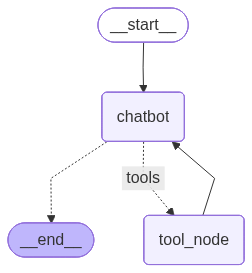

In [15]:
from IPython.display import display, Image
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not render graph:", e)


In [16]:
from IPython.display import Markdown, display

def render_markdown(md_string):
    display(Markdown(md_string))

def process_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()
    return message

def process_query(query, config=None):
    inputs = {"messages": [("user", query)]}
    message = process_stream(graph.stream(inputs, config, stream_mode="values"))
    render_markdown(f"## Answer:\n{message.content}")

In [17]:
process_query("What can you do?")

================================ Human Message =================================

What can you do?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (615766c4-10c8-4fd4-b100-08130d3d0a77)
 Call ID: 615766c4-10c8-4fd4-b100-08130d3d0a77
  Args:
    query: What can you do?
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "What Is a Digital Assistant?", "url": "https://librestream.com/blog/what-is-a-digital-assistant", "content": "### Personal Assistance\n\nOne of the primary roles of a digital assistant is to serve as a personal helper. Users can ask their digital assistants to perform tasks like setting alarms, scheduling meetings, sending messages, and making phone calls. This hands-free convenience allows users to manage their daily activities more efficiently, freeing up time for more important tasks.\n\n### Information Retrieval\n\nDigit

## Answer:
Based on the search results, it appears that I can perform a variety of tasks and provide information to users. Some of my capabilities include:

* Personal assistance: I can help with tasks such as setting alarms, scheduling meetings, sending messages, and making phone calls.
* Information retrieval: I can quickly retrieve information on topics such as weather forecasts, directions, restaurants, and stock prices.
* Smart home control: I can be integrated with smart home devices to control lights, thermostats, and other appliances.
* Answering complex questions: I can understand context and provide answers to complex questions.
* Anticipating user needs: I can anticipate what users need and provide personalized services.

Overall, my primary goal is to serve as a personal helper and make tasks easier for users.

In [18]:
process_query("hent siste kurs til Tesla?")

================================ Human Message =================================

hent siste kurs til Tesla?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (488d7d83-fe17-4920-ba93-c38c80a9b466)
 Call ID: 488d7d83-fe17-4920-ba93-c38c80a9b466
  Args:
    query: Tesla siste kurs
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Tesla: TSLA Stock Price Quote & News | Robinhood", "url": "https://robinhood.com/us/en/stocks/TSLA", "content": "As of 2026-05-21, Tesla(TSLA) stock has fluctuated between $419.05 and $426.95. The current price stands at $419.17, placing the stock +0.0% above today's low and -1.8% off the high.\n\nTesla(TSLA) shares are trading with a volume of 7.48M, against a daily average of 57.96M.\n\nIn the last year, Tesla(TSLA) shares hit a 52-week high of $498.83 and a 52-week low of $273.21.\n\nIn the last year, Tesla(TSLA

## Answer:
Basert på den siste informasjonen jeg har fått, er dagens kurs for Tesla $419.17.

In [20]:
process_query("Er det noen gode elver å fiske i nært Senja")

================================ Human Message =================================

Er det noen gode elver å fiske i nært Senja
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc73a130-6750-4037-94a6-9e89f6e9eb44)
 Call ID: fc73a130-6750-4037-94a6-9e89f6e9eb44
  Args:
    query: gode elver å fiske på Senja
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Lakselva på Senja | Norske Lakseelver", "url": "https://lakseelver.no/nb/elv-om-fisket/2021/lakselva-pa-senja", "content": "From June 15th to September 14th midnight (00:00) the maximum of three (3) single hooks or one (1) triple hook regardless tackle type.\n\nForbidden to use shrimp, bait fish, or otter.\n\nForbidden to use gaff to land salmon.\n\nFrom July 20th the use of wobbler, and kinds of lures in the river is forbidden.\n\nMaximum two (2) fishing poles per boat, however only one

## Answer:
Det er flere gode elver å fiske på Senja, blant annet Lakselva på Senja. Det er forskjellige regler for fisking på ulike tidspunkter av året og det er viktig å følge disse for å sikre en god og lovlig fangst.

Lakselva på Senja har en spesiell fiskeordning som gjelder fra 15. juni til 14. september, hvor det er tillatt å fiske med maksimalt tre enkeltkroker eller én trippelkrok. Det er også forbud mot bruk av reke, agnfisk og oter.

Det er flere båtoperatører på Senja som tilbyr fiskeeksperienser med profesjonelle båter og utstyr. Disse operatørene har erfaring og kunnskap om lokale fiskebestander og kan hjelpe deg å få en suksessfull fangst.

Det er også mulighet for å fiske i havområdene på Nord-Senja, hvor det ofte er stor fisk som tas. Men dette krever at du har din egen båt og utstyr, samt erfaring med fiske i saltvann.

I alle fall er det viktig å følge lokale regler og bestemmelser for fisking på Senja, samt å være respektfull overfor andre fiskere og den lokale miljøet.

In [21]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [23]:
# kompilerer graph med en checkpoint
graph = graph.builder.compile(checkpointer=memory)

In [24]:
config_user1 = {"thread_id": "user1_thread"}

In [25]:
process_query("Hvilke områder har jeg spurt om fiske ? ", config=config_user1)

================================ Human Message =================================

Hvilke områder har jeg spurt om fiske ? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (7096f68a-25e2-479a-9595-8da36923f357)
 Call ID: 7096f68a-25e2-479a-9595-8da36923f357
  Args:
    query: fiske
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "FISKE Definition & Meaning | Dictionary.com", "url": "https://www.dictionary.com/browse/fiske", "content": "# Fiske\n\n## noun\n\nJohn Edmund Fisk GreenJohn Fisk, 1842–1901, U.S. philosopher and historian.\n\nMinnie Maddern Marie Augusta Davey, 1865–1932, U.S. actress.\n\n## Example Sentences\n\nExamples are provided to illustrate real-world usage of words in context. Any\nopinions expressed do not reflect the views of Dictionary.com.\n\nFiske, in Austin, is pretty confident that her son, Ethan, will appreciate 

## Answer:
Du har spurt om fiske på flere områder, blant annet:

* Fiske som en personnavn (f.eks. John Fisk)
* Fiske som et begrep innen filosofi og historie
* Fiske som et begrep innen idrett (f.eks. fisksport)
* Fiske som et område innen utdanning (f.eks. Fiske Guide to Colleges)

 Det ser ut til at du har spurt om fiske i en bredere forstand, og jeg håper denne informasjonen er nyttig!

In [26]:
process_query("Hvor kan man fiske med flue i Målselv, Egil og meg selv Stig skal fiske ", config=config_user1)

================================ Human Message =================================

Hvor kan man fiske med flue i Målselv, Egil og meg selv Stig skal fiske 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (87849d29-6c05-4b24-9c0b-25bbce023cd3)
 Call ID: 87849d29-6c05-4b24-9c0b-25bbce023cd3
  Args:
    query: fiske med flue i Målselv, Egil og Stig
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "[PDF] MAALSELVDALEN - Lenvik Museum", "url": "https://www.lenvik-museum.no/meny5/Digitaleboeker/Maalselv_bygdebok_120109.pdf", "content": "skogbe- voksede og mangetungende bredder og rundt om alpetinder med de forskjelligste former. Mest karakteristisk storartet er partiet mod nord, der i en udstrækning af et snes kvadrat kilometer indesluttes af Maalselven, Bardoelven, Altevatn og Divielven, og som udelukkende bestaar af alper, lavtliggende dale m

## Answer:
Det ser ut til at det finnes flere steder hvor man kan fiske med flue i Målselv, blant annet:

* Maalselvdalen: Her er det mulighet for å fiske med flue i de mange små innsjøer og elvene.
* Bardo: Her er også mulighet for å fiske med flue i de lokale innsjøene og elvene.
* Fleskmo: Her er enkelte steder hvor man kan fiske med flue, men det er viktig å være oppmerksom på at dette må gjøres etter loven.

Det er viktig å huske at fiskeri i Norge må følge norske love og regler, inkludert lov om fiske og fangst av fisk og annet dyreliv. Det er også viktig å være respektfull overfor det lokale miljøet og andre som bruger de samme områdene.

Det er en god idé å sjekke lokale regler og tiltak før man planlegger et fiskeeventyr, og eventuelt kontakte lokale fiskere eller tilbydere for å få mer informasjon.

In [28]:
process_query("Hvem er jeg på fiske med i Målselv? ", config=config_user1)

================================ Human Message =================================

Hvem er jeg på fiske med i Målselv? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (15a8e958-b539-4285-85bd-5bee8ed2d88a)
 Call ID: 15a8e958-b539-4285-85bd-5bee8ed2d88a
  Args:
    query: fiske med i Målselv
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Fiske - Målselv Jeger og Fiskerforening", "url": "https://www.njff.no/troms/malselv/fiske", "content": "Finn ditt lokallag eller regionlag MIN SIDE\n\n%20(1).jpeg?quality=70)\n\n# Fiske\n\nMålselv jeger og fiskeforenings forvaltningsområde Laksefiske.\n\nStatskog har overlatt forvaltningen av laksefiske på sine eiendommer langs Målselv-vassdraget til Målselv JFF og Øverbygd JFF. På strekningen fra Målselvfossen til Trongen er denne oppgaven gitt til Målselv JFF.  \n Det er fiskeutvalget som har ansvare

## Answer:
Det ser ut til at det ikke er mulig å finne hvem du er sammen med på fiske i Målselv fra de søgeresultatene. Det kan være nyttige å sjekke lokale fiskerforeninger eller andre kilder for mer informasjon.

In [30]:
process_query("Kan du gi meg oversikt over alle gode sone for  fiske etter laks i Målselva? ", config=config_user1)

================================ Human Message =================================

Kan du gi meg oversikt over alle gode sone for  fiske etter laks i Målselva? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (72d8cfea-e51e-4994-9683-27aa524cf747)
 Call ID: 72d8cfea-e51e-4994-9683-27aa524cf747
  Args:
    query: gode soner for fiske etter laks i Målselva
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Fiske - Målselv Jeger og Fiskerforening", "url": "https://www.njff.no/troms/malselv/fiske", "content": "er fylt».  MJFF har med bakgrunn i antall kort vi selger på våre soner, begrenset uttaket til 2 laks pr fisker. Ellers gjelder de samme kvotereguleringene som for resten av vassdraget. | [...] Finn ditt lokallag eller regionlag MIN SIDE\n\n%20(1).jpeg?quality=70)\n\n# Fiske\n\nMålselv jeger og fiskeforenings forvaltningsområde Laksefiske

## Answer:
Det er flere soner for fiske etter laks i Målselva, blant annet:

* Sone 1: Ovenfor fossen
* Sone 2: Fra øvre grense av sone 1 til Sandbakken/Målselv kirke
* Sone 3: Fra samløpet mellom Bardu- og Målselva og ned vassdraget

 Det er også noen spesielle regler for hver son, så det er viktig å sjekke disse før du går på fiske.

Det er også noen andre informasjoner som kan være nyttige å vite:

* Fiskesesonen varer fra 15. juni til og med 26. august
* Det er maksimum to laks per fisker
* Det er tillatt å fiske med sluk, flue, mark, spinner og wobbler
* Det er forbudt å bruke reke, agnfisk og oter
* Det er ikke tillatt å bruke huk eller klepp ved landing av fisk

In [31]:
process_query("Det skal være flere soner lengre opp i Målselva inkludert Dividalselva ", config=config_user1)


================================ Human Message =================================

Det skal være flere soner lengre opp i Målselva inkludert Dividalselva 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (51f178cd-88ef-4390-85e5-76681a397b90)
 Call ID: 51f178cd-88ef-4390-85e5-76681a397b90
  Args:
    query: Målselv fiske soner inkludert Dividalselva
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Øverbygd JFF - Laksefiske i Målselva, Divielva og Rostadelva  | inatur.no", "url": "https://www.inatur.no/laksefiske/56c19a34e4b0766d8b42bd32", "content": "Fiskebestemmelsene og etterfølgelse av disse Ved kjøp av fiskekort aksepteres fiskeregler for sesongen, samt reaksjoner ved brudd.  \nEier/ utleier/ kortselger har plikt til å orientere fiskere om det gjeldende regelverket i elva. Den enkelte fisker skal, før fisket starter,  \nsette seg inn 

## Answer:
Det er flere soner for fiske etter laks i Målselva, inkludert Dividalselva. Her er noen av de mest interessante informasjonene:

* Øverbygd JFF tilbyr laksefiske i øvre del av Målselva, inkludert Dividalselva og Rostadelva.
* Det er flere soner for fiske etter laks i Målselva, inkludert Sone 1, Sone 2, Sone 3 (Båtstøa/Åra) og Sone 4 (Nedre Trongen).
* Øverbygd JFF disponerer flere soner i målselva på vegne av statskog.
* Det er KUN tillatt å fiske fra land på sørsiden av elva, inkludert Dividalselva.
* I tillegg er fiske tillatt fra båt.

Det er viktig å huske at det er flere regler og bestemmelser som gjelder for fisket i Målselva, inkludert kvoter, fredningstider og regler for utleie av båter. Det er også viktig å respektere de lokale foreninger og deres regler for fisket.

Det er mange flere detaljer omfattende informasjon om fisket i Målselva, inkludert bestemmelsene for hver son, kvoter, fredningstider og mer.

In [32]:
process_query("Kan du gi meg detaljene for sone 10, antall fiskere, redskap og når fisken biter best? ", config=config_user1)


================================ Human Message =================================

Kan du gi meg detaljene for sone 10, antall fiskere, redskap og når fisken biter best? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (af001d1d-442c-4ee4-bd8c-bb0ab363a47f)
 Call ID: af001d1d-442c-4ee4-bd8c-bb0ab363a47f
  Args:
    query: Målselva sone 10 detaljer, antall fiskere, redskap, beste bytingstid
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Laksefiske i Målselva og Målselvfossen", "url": "https://tips.inatur.no/laksefiske-troms/laksefiske-i-malselva-og-malselvfossen/101488", "content": "Målselva er en av Norges lengste lakseelver og renner gjennom et vekslende og majestetisk landskap. Over halvparten av laksen i elva gyter over Målselvfossen.\n\nElva endrer seg markant på sin vei til havet. I de øvre delene er elva raskere, mer variert med 

## Answer:
Det var ikke mulig å finne informasjonen du søkte etter. Jeg kunne bare finne generelle informasjoner om fisket i Målselva og detaljer for andre soner enn sone 10.

Men jeg kan anbefale deg å sjekke nettstedet Norske Lakseelver eller lokale aviser for opplysninger om fisket i Målselva. De kan ha mer informasjon om sone 10, antall fiskere, redskap og beste bytingstid.

Jeg beklager at jeg ikke kunne finne det du søkte etter.